In [ ]:
%pip install pillow pandas imagehash matplotlib

Note: you may need to restart the kernel to use updated packages.


In [4]:
import sys
print(sys.executable)

!{sys.executable} -m pip install ImageHash Pillow pandas matplotlib

c:\Users\sarun\AppData\Local\Programs\Python\Python311\python.exe
  Using cached ImageHash-4.3.2-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached pywavelets-1.9.0-cp311-cp311-win_amd64.whl.metadata (7.6 kB)
Using cached ImageHash-4.3.2-py2.py3-none-any.whl (296 kB)
Using cached pywavelets-1.9.0-cp311-cp311-win_amd64.whl (4.2 MB)

   ---------------------------------------- 0/2 [PyWavelets]
   ---------------------------------------- 2/2 [ImageHash]



In [5]:
import sys
import imagehash

print("Python:", sys.executable)
print("ImageHash imported successfully")

Python: c:\Users\sarun\AppData\Local\Programs\Python\Python311\python.exe
ImageHash imported successfully


In [7]:
import sys

print("Notebook Python:")
print(sys.executable)

Notebook Python:
c:\Users\sarun\AppData\Local\Programs\Python\Python311\python.exe


In [1]:
import sys

print("Installing into:", sys.executable)

!{sys.executable} -m pip install --upgrade --force-reinstall numpy matplotlib pillow pandas ImageHash

Installing into: c:\Users\sarun\OneDrive\Desktop\cesppl-internship\.venv\Scripts\python.exe
  Using cached numpy-2.4.6-cp311-cp311-win_amd64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.11.1-cp311-cp311-win_amd64.whl.metadata (80 kB)
  Using cached pillow-12.3.0-cp311-cp311-win_amd64.whl.metadata (9.3 kB)
  Using cached ImageHash-4.3.2-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp311-cp311-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp311-cp311-win_amd64.whl.metadata (5.2 kB)
  Using cached packaging-26.2-py3-none-any.whl.metadata (3.5 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached tzdata-2026.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached pywavelets-1.9.0-cp311-cp311-wi

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jupyter-server 2.20.0 requires overrides>=5.0; python_version < "3.12", which is not installed.


In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import imagehash
import pandas as pd
from PIL import Image, ImageOps

print("Python:", sys.executable)
print("NumPy:", np.__version__)
print("Matplotlib imported successfully")
print("Pandas:", pd.__version__)
print("All packages imported successfully")

Python: c:\Users\sarun\cesppl_env\Scripts\python.exe
NumPy: 2.4.6
Matplotlib imported successfully
Pandas: 3.0.5
All packages imported successfully


In [4]:
from pathlib import Path
from collections import defaultdict, Counter
from PIL import Image, ImageOps, UnidentifiedImageError
import imagehash
import shutil
import statistics
import re
import os
import sys
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
print("Libraries imported successfully.")

Libraries imported successfully.


In [5]:
PROJECT_ROOT = Path(
    r"C:\Users\sarun\OneDrive\Desktop\cesppl-internship"
)

RAW_DATASET = PROJECT_ROOT / "data" / "cesppl_raw"
PROCESSED_DATASET = PROJECT_ROOT / "data" / "cesppl_processed"
CLASSES_FILE = PROJECT_ROOT / "CLASSES.md"

print("Project root     :", PROJECT_ROOT)
print("Raw dataset      :", RAW_DATASET)
print("Processed dataset:", PROCESSED_DATASET)
print("CLASSES.md       :", CLASSES_FILE)

print("\nPath checks:")
print("Project exists :", PROJECT_ROOT.exists())
print("Raw data exists:", RAW_DATASET.exists())
print("Classes exists :", CLASSES_FILE.exists())

Project root     : C:\Users\sarun\OneDrive\Desktop\cesppl-internship
Raw dataset      : C:\Users\sarun\OneDrive\Desktop\cesppl-internship\data\cesppl_raw
Processed dataset: C:\Users\sarun\OneDrive\Desktop\cesppl-internship\data\cesppl_processed
CLASSES.md       : C:\Users\sarun\OneDrive\Desktop\cesppl-internship\CLASSES.md

Path checks:
Project exists : True
Raw data exists: True
Classes exists : True


In [6]:
if not PROJECT_ROOT.exists():
    raise FileNotFoundError(
        f"Project folder was not found:\n{PROJECT_ROOT}"
    )

if not RAW_DATASET.exists():
    raise FileNotFoundError(
        f"Raw dataset was not found:\n{RAW_DATASET}"
    )

if not CLASSES_FILE.exists():
    raise FileNotFoundError(
        f"CLASSES.md was not found:\n{CLASSES_FILE}"
    )

print("All required paths are available.")

All required paths are available.


In [7]:
def read_classes(classes_path: Path) -> list[str]:
    classes = []

    for line in classes_path.read_text(encoding="utf-8").splitlines():
        line = line.strip()

        # Read Markdown bullet items such as:
        # - BIN_LIFTING
        if line.startswith("-"):
            class_name = line.lstrip("-").strip()

            if class_name:
                classes.append(class_name)

    if not classes:
        raise ValueError(
            "No class names were found in CLASSES.md. "
            "Expected Markdown bullet items such as '- BIN_LIFTING'."
        )

    return classes


CANONICAL_CLASSES = read_classes(CLASSES_FILE)

# Convert canonical names to the actual raw folder names.
# Example: BIN_LIFTING -> BIN LIFTING
FOLDER_CLASSES = [
    class_name.replace("_", " ")
    for class_name in CANONICAL_CLASSES
]

print("Classes loaded:", len(CANONICAL_CLASSES))

for canonical_name, folder_name in zip(
    CANONICAL_CLASSES,
    FOLDER_CLASSES
):
    print(f"{canonical_name:30} -> {folder_name}")

Classes loaded: 10
BIN_LIFTING                    -> BIN LIFTING
BIN_WASHING                    -> BIN WASHING
GATE_MEETING                   -> GATE MEETING
LFC                            -> LFC
MANUAL_BEACH_CLEANING          -> MANUAL BEACH CLEANING
MECHANICAL_SWEEPING            -> MECHANICAL SWEEPING
MECHANIZED_BEACH_CLEANING      -> MECHANIZED BEACH CLEANING
PRIMARY_COLLECTION             -> PRIMARY COLLECTION
ROAD_SWEEPING                  -> ROAD SWEEPING
SECONDARY_VEHICLES             -> SECONDARY VEHICLES


In [8]:
missing_folders = []

for folder_name in FOLDER_CLASSES:
    class_folder = RAW_DATASET / folder_name

    if not class_folder.exists():
        missing_folders.append(folder_name)

if missing_folders:
    print("Missing folders:")

    for folder_name in missing_folders:
        print("-", folder_name)

    raise FileNotFoundError(
        "One or more expected class folders are missing."
    )

print("All ten raw class folders were found.")

All ten raw class folders were found.


In [14]:
raw_count_rows = []

for canonical_name, folder_name in zip(
    CANONICAL_CLASSES,
    FOLDER_CLASSES
):
    class_folder = RAW_DATASET / folder_name

    total_files = sum(
        1
        for path in class_folder.glob("*")
        if path.is_file()
    )

    raw_count_rows.append({
        "class": canonical_name,
        "raw_files": total_files
    })

for row in raw_count_rows:
    print(f"{row['class']:30} : {row['raw_files']}")

total_raw_files = sum(
    row["raw_files"]
    for row in raw_count_rows
)

print("\nTotal raw files:", total_raw_files)

BIN_LIFTING                    : 166
BIN_WASHING                    : 327
GATE_MEETING                   : 367
LFC                            : 217
MANUAL_BEACH_CLEANING          : 1384
MECHANICAL_SWEEPING            : 284
MECHANIZED_BEACH_CLEANING      : 302
PRIMARY_COLLECTION             : 208
ROAD_SWEEPING                  : 530
SECONDARY_VEHICLES             : 394

Total raw files: 4179


In [9]:
if PROCESSED_DATASET.exists():
    existing_files = [
        path
        for path in PROCESSED_DATASET.rglob("*")
        if path.is_file()
    ]

    if existing_files:
        raise FileExistsError(
            f"The processed folder already contains "
            f"{len(existing_files)} files:\n"
            f"{PROCESSED_DATASET}\n\n"
            "Do not continue until you decide whether these files "
            "belong to an earlier preprocessing run."
        )

PROCESSED_DATASET.mkdir(
    parents=True,
    exist_ok=True
)

for folder_name in FOLDER_CLASSES:
    (PROCESSED_DATASET / folder_name).mkdir(
        parents=True,
        exist_ok=True
    )

print("Processed folder structure is ready.")

Processed folder structure is ready.


In [10]:
IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".gif",
    ".tif",
    ".tiff",
    ".webp"
}

SYSTEM_FILES = {
    "thumbs.db",
    "desktop.ini",
    ".ds_store"
}

print("Supported image extensions configured.")

Supported image extensions configured.


In [11]:
def sanitize_filename_part(text: str) -> str:
    text = re.sub(r"[^A-Za-z0-9_-]+", "_", text)
    return text.strip("_")


def create_output_path(
    source_path: Path,
    raw_class_folder: Path,
    processed_class_folder: Path
) -> Path:
    relative_path = source_path.relative_to(raw_class_folder)

    # Include relative parent folder names if nested folders exist.
    parent_text = "_".join(relative_path.parent.parts)

    if parent_text == ".":
        parent_text = ""

    stem = sanitize_filename_part(source_path.stem)
    extension_label = sanitize_filename_part(
        source_path.suffix.lower().lstrip(".")
    )

    name_parts = [
        part
        for part in [parent_text, stem, extension_label]
        if part
    ]

    output_stem = "__".join(name_parts)
    output_path = processed_class_folder / f"{output_stem}.jpg"

    counter = 1

    while output_path.exists():
        output_path = (
            processed_class_folder /
            f"{output_stem}__{counter}.jpg"
        )
        counter += 1

    return output_path


print("Output filename helper created.")

Output filename helper created.


In [12]:
def sanitize_filename_part(text: str) -> str:
    text = re.sub(r"[^A-Za-z0-9_-]+", "_", text)
    return text.strip("_")


def create_output_path(
    source_path: Path,
    raw_class_folder: Path,
    processed_class_folder: Path
) -> Path:
    relative_path = source_path.relative_to(raw_class_folder)

    # Include relative parent folder names if nested folders exist.
    parent_text = "_".join(relative_path.parent.parts)

    if parent_text == ".":
        parent_text = ""

    stem = sanitize_filename_part(source_path.stem)
    extension_label = sanitize_filename_part(
        source_path.suffix.lower().lstrip(".")
    )

    name_parts = [
        part
        for part in [parent_text, stem, extension_label]
        if part
    ]

    output_stem = "__".join(name_parts)
    output_path = processed_class_folder / f"{output_stem}.jpg"

    counter = 1

    while output_path.exists():
        output_path = (
            processed_class_folder /
            f"{output_stem}__{counter}.jpg"
        )
        counter += 1

    return output_path


print("Output filename helper created.")

Output filename helper created.


In [13]:
from pathlib import Path
from PIL import Image, ImageOps


def clean_and_resize(
    src_path: Path,
    dst_path: Path,
    target_size: int = 320
):
    """
    Correct EXIF orientation, resize the shorter edge,
    centre-crop to target_size × target_size,
    convert to RGB, and save as JPEG.
    """

    if target_size <= 0:
        raise ValueError("target_size must be greater than zero.")

    dst_path.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    with Image.open(src_path) as image:
        # Correct phone rotation using EXIF information
        image = ImageOps.exif_transpose(image)

        original_width, original_height = image.size

        if original_width <= 0 or original_height <= 0:
            raise ValueError(
                f"Invalid image dimensions: "
                f"{original_width}x{original_height}"
            )

        image = image.convert("RGB")

        # Resize so that the shorter edge becomes 320
        scale = target_size / min(
            original_width,
            original_height
        )

        resized_width = max(
            target_size,
            round(original_width * scale)
        )

        resized_height = max(
            target_size,
            round(original_height * scale)
        )

        image = image.resize(
            (resized_width, resized_height),
            Image.Resampling.LANCZOS
        )

        # Centre crop
        left = (resized_width - target_size) // 2
        top = (resized_height - target_size) // 2
        right = left + target_size
        bottom = top + target_size

        image = image.crop(
            (left, top, right, bottom)
        )

        image.save(
            dst_path,
            format="JPEG",
            quality=90,
            optimize=True
        )

    return original_width, original_height


print("clean_and_resize() is defined successfully.")

clean_and_resize() is defined successfully.


In [14]:
test_source = None
test_class_folder = None

for folder_name in FOLDER_CLASSES:
    candidate_folder = RAW_DATASET / folder_name

    candidates = [
        path
        for path in candidate_folder.rglob("*")
        if (
            path.is_file()
            and path.suffix.lower() in IMAGE_EXTENSIONS
        )
    ]

    if candidates:
        test_source = candidates[0]
        test_class_folder = folder_name
        break

if test_source is None:
    raise FileNotFoundError(
        "No supported images were found for testing."
    )

TEST_OUTPUT_FOLDER = (
    PROJECT_ROOT / "data" / "_preprocessing_test"
)

TEST_OUTPUT_FOLDER.mkdir(
    parents=True,
    exist_ok=True
)

test_output = TEST_OUTPUT_FOLDER / "test_output.jpg"

original_size = clean_and_resize(
    test_source,
    test_output,
    target_size=320
)

with Image.open(test_output) as test_image:
    final_size = test_image.size
    final_mode = test_image.mode

print("Source       :", test_source)
print("Original size:", original_size)
print("Output       :", test_output)
print("Final size   :", final_size)
print("Final mode   :", final_mode)

Source       : C:\Users\sarun\OneDrive\Desktop\cesppl-internship\data\cesppl_raw\BIN LIFTING\image744.png
Original size: (615, 818)
Output       : C:\Users\sarun\OneDrive\Desktop\cesppl-internship\data\_preprocessing_test\test_output.jpg
Final size   : (320, 320)
Final mode   : RGB


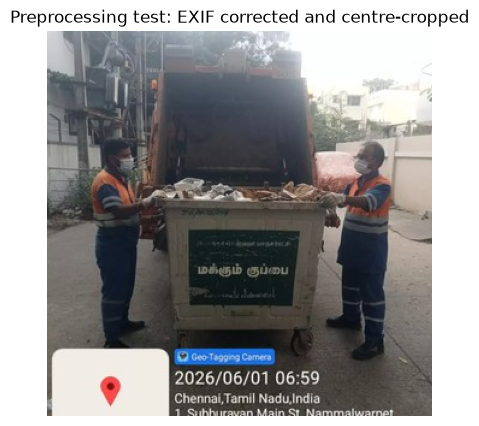

In [15]:
with Image.open(test_output) as test_image:
    plt.figure(figsize=(5, 5))
    plt.imshow(test_image)
    plt.axis("off")
    plt.title("Preprocessing test: EXIF corrected and centre-cropped")
    plt.show()

In [16]:
shutil.rmtree(
    TEST_OUTPUT_FOLDER,
    ignore_errors=True
)

print("Temporary test folder removed.")

Temporary test folder removed.


In [17]:
processing_rows = []
processing_failure_rows = []

for canonical_name, folder_name in zip(
    CANONICAL_CLASSES,
    FOLDER_CLASSES
):
    raw_class_folder = RAW_DATASET / folder_name
    processed_class_folder = PROCESSED_DATASET / folder_name

    source_files = sorted(
        path
        for path in raw_class_folder.rglob("*")
        if path.is_file()
    )

    class_successes = 0
    class_failures = 0
    class_skipped = 0

    for source_path in source_files:
        extension = source_path.suffix.lower()

        if (
            source_path.name.lower() in SYSTEM_FILES
            or extension not in IMAGE_EXTENSIONS
        ):
            class_skipped += 1

            processing_failure_rows.append({
                "class": canonical_name,
                "source_file": str(
                    source_path.relative_to(RAW_DATASET)
                ),
                "status": "skipped",
                "reason": "unsupported_or_system_file",
                "error": ""
            })

            continue

        try:
            output_path = create_output_path(
                source_path,
                raw_class_folder,
                processed_class_folder
            )

            original_width, original_height = clean_and_resize(
                source_path,
                output_path,
                target_size=320
            )

            processing_rows.append({
                "class": canonical_name,
                "source_file": str(
                    source_path.relative_to(RAW_DATASET)
                ),
                "processed_file": str(
                    output_path.relative_to(PROCESSED_DATASET)
                ),
                "original_width": original_width,
                "original_height": original_height,
                "processed_width": 320,
                "processed_height": 320,
                "status": "success"
            })

            class_successes += 1

        except (
            UnidentifiedImageError,
            OSError,
            ValueError,
            RuntimeError,
            SyntaxError
        ) as error:
            class_failures += 1

            processing_failure_rows.append({
                "class": canonical_name,
                "source_file": str(
                    source_path.relative_to(RAW_DATASET)
                ),
                "status": "failed",
                "reason": "processing_error",
                "error": str(error)[:500]
            })

    print(
        f"{canonical_name}: "
        f"{class_successes} processed, "
        f"{class_failures} failed, "
        f"{class_skipped} skipped"
    )

print("\nFull preprocessing completed.")

BIN_LIFTING: 166 processed, 0 failed, 0 skipped
BIN_WASHING: 327 processed, 0 failed, 0 skipped
GATE_MEETING: 367 processed, 0 failed, 0 skipped
LFC: 217 processed, 0 failed, 0 skipped
MANUAL_BEACH_CLEANING: 1384 processed, 0 failed, 0 skipped
MECHANICAL_SWEEPING: 284 processed, 0 failed, 0 skipped
MECHANIZED_BEACH_CLEANING: 302 processed, 0 failed, 0 skipped
PRIMARY_COLLECTION: 208 processed, 0 failed, 0 skipped
ROAD_SWEEPING: 530 processed, 0 failed, 0 skipped
SECONDARY_VEHICLES: 394 processed, 0 failed, 0 skipped

Full preprocessing completed.


In [18]:
processing_df = pd.DataFrame(processing_rows)

processing_failures_df = pd.DataFrame(
    processing_failure_rows,
    columns=[
        "class",
        "source_file",
        "status",
        "reason",
        "error"
    ]
)

print("Successfully processed:", len(processing_df))
print("Failures or skipped   :", len(processing_failures_df))

if not processing_failures_df.empty:
    display(processing_failures_df)

Successfully processed: 4179
Failures or skipped   : 0


In [19]:
processed_verification_rows = []
verification_failure_rows = []

for canonical_name, folder_name in zip(
    CANONICAL_CLASSES,
    FOLDER_CLASSES
):
    class_folder = PROCESSED_DATASET / folder_name

    processed_files = sorted(
        path
        for path in class_folder.rglob("*.jpg")
        if path.is_file()
    )

    valid_count = 0
    wrong_size_count = 0
    wrong_mode_count = 0

    for image_path in processed_files:
        try:
            with Image.open(image_path) as image:
                image.load()

                if image.size != (320, 320):
                    wrong_size_count += 1

                    verification_failure_rows.append({
                        "class": canonical_name,
                        "file": str(
                            image_path.relative_to(PROCESSED_DATASET)
                        ),
                        "reason": "wrong_size",
                        "details": str(image.size)
                    })

                    continue

                if image.mode != "RGB":
                    wrong_mode_count += 1

                    verification_failure_rows.append({
                        "class": canonical_name,
                        "file": str(
                            image_path.relative_to(PROCESSED_DATASET)
                        ),
                        "reason": "wrong_mode",
                        "details": image.mode
                    })

                    continue

                valid_count += 1

        except Exception as error:
            verification_failure_rows.append({
                "class": canonical_name,
                "file": str(
                    image_path.relative_to(PROCESSED_DATASET)
                ),
                "reason": "unreadable_processed_image",
                "details": str(error)[:300]
            })

    processed_verification_rows.append({
        "class": canonical_name,
        "processed_files": len(processed_files),
        "valid_320x320_rgb": valid_count,
        "wrong_size": wrong_size_count,
        "wrong_mode": wrong_mode_count
    })

processed_verification_df = pd.DataFrame(
    processed_verification_rows
)

verification_failures_df = pd.DataFrame(
    verification_failure_rows
)

display(processed_verification_df)

print(
    "Total verified processed images:",
    int(
        processed_verification_df[
            "valid_320x320_rgb"
        ].sum()
    )
)

,class,processed_files,valid_320x320_rgb,wrong_size,wrong_mode
0,BIN_LIFTING,166,166,0,0
1,BIN_WASHING,327,327,0,0
2,GATE_MEETING,367,367,0,0
3,LFC,217,217,0,0
4,MANUAL_BEACH_CLEANING,1384,1384,0,0
5,MECHANICAL_SWEEPING,284,284,0,0
6,MECHANIZED_BEACH_CLEANING,302,302,0,0
7,PRIMARY_COLLECTION,208,208,0,0
8,ROAD_SWEEPING,530,530,0,0
9,SECONDARY_VEHICLES,394,394,0,0


Total verified processed images: 4179


In [20]:
hash_rows = []
hash_failure_rows = []

for canonical_name, folder_name in zip(
    CANONICAL_CLASSES,
    FOLDER_CLASSES
):
    class_folder = PROCESSED_DATASET / folder_name

    image_files = sorted(
        path
        for path in class_folder.rglob("*.jpg")
        if path.is_file()
    )

    for image_path in image_files:
        try:
            with Image.open(image_path) as image:
                image = image.convert("RGB")
                perceptual_hash = imagehash.phash(image)

            hash_rows.append({
                "class": canonical_name,
                "file": str(
                    image_path.relative_to(PROCESSED_DATASET)
                ),
                "phash": str(perceptual_hash)
            })

        except Exception as error:
            hash_failure_rows.append({
                "class": canonical_name,
                "file": str(
                    image_path.relative_to(PROCESSED_DATASET)
                ),
                "error": str(error)[:300]
            })

hash_df = pd.DataFrame(hash_rows)
hash_failures_df = pd.DataFrame(hash_failure_rows)

print("Hashes computed:", len(hash_df))
print("Hash failures :", len(hash_failures_df))

Hashes computed: 4179
Hash failures : 0


In [21]:
identical_groups = []

for (class_name, phash_value), group in hash_df.groupby(
    ["class", "phash"]
):
    if len(group) > 1:
        files = sorted(group["file"].tolist())

        identical_groups.append({
            "class": class_name,
            "phash": phash_value,
            "group_size": len(files),
            "keep_file": files[0],
            "duplicate_files": files[1:]
        })

print("Identical hash groups:", len(identical_groups))

extra_identical_files = sum(
    group["group_size"] - 1
    for group in identical_groups
)

print(
    "Files marked as identical-hash duplicates:",
    extra_identical_files
)

Identical hash groups: 559
Files marked as identical-hash duplicates: 563


In [22]:
identical_display_rows = []

for group_number, group in enumerate(
    identical_groups,
    start=1
):
    identical_display_rows.append({
        "group_id": group_number,
        "class": group["class"],
        "phash": group["phash"],
        "group_size": group["group_size"],
        "keep_file": group["keep_file"],
        "duplicate_files": " | ".join(
            group["duplicate_files"]
        )
    })

identical_groups_df = pd.DataFrame(
    identical_display_rows,
    columns=[
        "group_id",
        "class",
        "phash",
        "group_size",
        "keep_file",
        "duplicate_files"
    ]
)

display(identical_groups_df)

,group_id,class,phash,group_size,keep_file,duplicate_files
0,1,BIN_WASHING,a8aa7f36c8ce9321,3,BIN WASHING\WhatsApp_Image_2026-07-03_at_5_15_...,BIN WASHING\WhatsApp_Image_2026-07-03_at_5_16_...
1,2,GATE_MEETING,a28f95707e4f039a,2,GATE MEETING\WhatsApp_Image_2026-07-03_at_2_20...,GATE MEETING\WhatsApp_Image_2026-07-03_at_2_50...
2,3,GATE_MEETING,c287f4d5707a4e4c,2,GATE MEETING\WhatsApp_Image_2026-07-09_at_11_1...,GATE MEETING\WhatsApp_Image_2026-07-09_at_11_1...
3,4,GATE_MEETING,d2cdcdd692093276,2,GATE MEETING\WhatsApp_Image_2026-07-02_at_10_2...,GATE MEETING\WhatsApp_Image_2026-07-02_at_10_4...
4,5,GATE_MEETING,d88b7f364762490b,2,GATE MEETING\WhatsApp_Image_2026-07-09_at_11_1...,GATE MEETING\WhatsApp_Image_2026-07-09_at_11_1...
...,...,...,...,...,...,...
554,555,SECONDARY_VEHICLES,f6a686a3bb1e41d0,2,SECONDARY VEHICLES\WhatsApp_Image_2026-07-07_a...,SECONDARY VEHICLES\WhatsApp_Image_2026-07-07_a...
555,556,SECONDARY_VEHICLES,f7a7b29058683b13,2,SECONDARY VEHICLES\image737__jpeg.jpg,SECONDARY VEHICLES\verified_image737__jpeg.jpg
556,557,SECONDARY_VEHICLES,f83e7bf802078939,2,SECONDARY VEHICLES\image650__jpeg.jpg,SECONDARY VEHICLES\verified_image650__jpeg.jpg
557,558,SECONDARY_VEHICLES,f8df662758d09720,2,SECONDARY VEHICLES\image649__jpeg.jpg,SECONDARY VEHICLES\verified_image649__jpeg.jpg


In [23]:
IDENTICAL_REVIEW_FOLDER = (
    PROJECT_ROOT / "dedup_review" / "identical_hash_groups"
)

IDENTICAL_REVIEW_FOLDER.mkdir(
    parents=True,
    exist_ok=True
)


def create_contact_sheet(
    relative_files: list[str],
    output_path: Path,
    title: str,
    thumbnail_size: int = 220
) -> None:
    images = []

    for relative_file in relative_files:
        full_path = PROCESSED_DATASET / relative_file

        with Image.open(full_path) as image:
            image = image.convert("RGB")
            image.thumbnail(
                (thumbnail_size, thumbnail_size)
            )
            images.append((relative_file, image.copy()))

    columns = min(4, len(images))
    rows = (len(images) + columns - 1) // columns

    figure_width = columns * 4
    figure_height = rows * 4.5

    fig, axes = plt.subplots(
        rows,
        columns,
        figsize=(figure_width, figure_height)
    )

    if rows == 1 and columns == 1:
        axes = [axes]
    elif rows == 1:
        axes = list(axes)
    else:
        axes = list(axes.flat)

    for axis in axes:
        axis.axis("off")

    for axis, (filename, image) in zip(axes, images):
        axis.imshow(image)
        axis.set_title(
            Path(filename).name,
            fontsize=8
        )
        axis.axis("off")

    fig.suptitle(title)
    plt.tight_layout()
    fig.savefig(
        output_path,
        dpi=150,
        bbox_inches="tight"
    )
    plt.close(fig)


for group_number, group in enumerate(
    identical_groups,
    start=1
):
    group_files = [
        group["keep_file"],
        *group["duplicate_files"]
    ]

    output_path = (
        IDENTICAL_REVIEW_FOLDER /
        f"identical_group_{group_number:04d}.jpg"
    )

    create_contact_sheet(
        group_files,
        output_path,
        title=(
            f"Identical pHash group {group_number} – "
            f"{group['class']}"
        )
    )

print(
    "Identical-hash review sheets saved to:",
    IDENTICAL_REVIEW_FOLDER
)

Identical-hash review sheets saved to: C:\Users\sarun\OneDrive\Desktop\cesppl-internship\dedup_review\identical_hash_groups


In [24]:
IDENTICAL_GROUPS_TO_KEEP_ALL = []

print(
    "Groups protected from duplicate removal:",
    IDENTICAL_GROUPS_TO_KEEP_ALL
)

Groups protected from duplicate removal: []


In [25]:
DUPLICATE_QUARANTINE = (
    PROJECT_ROOT /
    "data" /
    "cesppl_duplicate_quarantine"
)

deduplication_rows = []

for group_number, group in enumerate(
    identical_groups,
    start=1
):
    if group_number in IDENTICAL_GROUPS_TO_KEEP_ALL:
        continue

    for duplicate_relative_path in group["duplicate_files"]:

        duplicate_path = (
            PROCESSED_DATASET /
            duplicate_relative_path
        )

        quarantine_path = (
            DUPLICATE_QUARANTINE /
            duplicate_relative_path
        )

        quarantine_path.parent.mkdir(
            parents=True,
            exist_ok=True
        )

        if duplicate_path.exists():

            shutil.move(
                str(duplicate_path),
                str(quarantine_path)
            )

            deduplication_rows.append({
                "group_id": group_number,
                "class": group["class"],
                "kept_file": group["keep_file"],
                "removed_file": duplicate_relative_path,
                "hash_distance": 0,
                "reason": "identical_perceptual_hash",
                "action": "moved_to_quarantine"
            })

deduplication_df = pd.DataFrame(
    deduplication_rows,
    columns=[
        "group_id",
        "class",
        "kept_file",
        "removed_file",
        "hash_distance",
        "reason",
        "action"
    ]
)

print(
    "Identical-hash duplicates moved to quarantine:",
    len(deduplication_df)
)

display(deduplication_df.head(20))

Identical-hash duplicates moved to quarantine: 563


,group_id,class,kept_file,removed_file,hash_distance,reason,action
0,1,BIN_WASHING,BIN WASHING\WhatsApp_Image_2026-07-03_at_5_15_...,BIN WASHING\WhatsApp_Image_2026-07-03_at_5_16_...,0,identical_perceptual_hash,moved_to_quarantine
1,1,BIN_WASHING,BIN WASHING\WhatsApp_Image_2026-07-03_at_5_15_...,BIN WASHING\WhatsApp_Image_2026-07-03_at_5_17_...,0,identical_perceptual_hash,moved_to_quarantine
2,2,GATE_MEETING,GATE MEETING\WhatsApp_Image_2026-07-03_at_2_20...,GATE MEETING\WhatsApp_Image_2026-07-03_at_2_50...,0,identical_perceptual_hash,moved_to_quarantine
3,3,GATE_MEETING,GATE MEETING\WhatsApp_Image_2026-07-09_at_11_1...,GATE MEETING\WhatsApp_Image_2026-07-09_at_11_1...,0,identical_perceptual_hash,moved_to_quarantine
4,4,GATE_MEETING,GATE MEETING\WhatsApp_Image_2026-07-02_at_10_2...,GATE MEETING\WhatsApp_Image_2026-07-02_at_10_4...,0,identical_perceptual_hash,moved_to_quarantine
5,5,GATE_MEETING,GATE MEETING\WhatsApp_Image_2026-07-09_at_11_1...,GATE MEETING\WhatsApp_Image_2026-07-09_at_11_1...,0,identical_perceptual_hash,moved_to_quarantine
6,6,GATE_MEETING,GATE MEETING\WhatsApp_Image_2026-07-02_at_7_13...,GATE MEETING\WhatsApp_Image_2026-07-02_at_7_13...,0,identical_perceptual_hash,moved_to_quarantine
7,7,GATE_MEETING,GATE MEETING\WhatsApp_Image_2026-07-01_at_6_29...,GATE MEETING\WhatsApp_Image_2026-07-01_at_6_30...,0,identical_perceptual_hash,moved_to_quarantine
8,7,GATE_MEETING,GATE MEETING\WhatsApp_Image_2026-07-01_at_6_29...,GATE MEETING\WhatsApp_Image_2026-07-01_at_7_58...,0,identical_perceptual_hash,moved_to_quarantine
9,8,LFC,LFC\image110__jpeg.jpg,LFC\verified_image110__jpeg.jpg,0,identical_perceptual_hash,moved_to_quarantine


In [26]:
remaining_processed_count = sum(
    1
    for path in PROCESSED_DATASET.rglob("*.jpg")
    if path.is_file()
)

quarantined_count = sum(
    1
    for path in DUPLICATE_QUARANTINE.rglob("*.jpg")
    if path.is_file()
)

print("Images remaining in processed folder:", remaining_processed_count)
print("Images moved to quarantine         :", quarantined_count)
print("Original processed total           :", len(hash_df))

print(
    "Count verification:",
    remaining_processed_count + quarantined_count
)

Images remaining in processed folder: 3616
Images moved to quarantine         : 563
Original processed total           : 4179
Count verification: 4179


In [27]:
IDENTICAL_DEDUP_LOG_PATH = (
    PROJECT_ROOT / "identical_duplicates_log.csv"
)

deduplication_df.to_csv(
    IDENTICAL_DEDUP_LOG_PATH,
    index=False,
    encoding="utf-8"
)

print("Saved:", IDENTICAL_DEDUP_LOG_PATH)

Saved: C:\Users\sarun\OneDrive\Desktop\cesppl-internship\identical_duplicates_log.csv


In [28]:
remaining_hash_rows = []

for canonical_name, folder_name in zip(
    CANONICAL_CLASSES,
    FOLDER_CLASSES
):
    class_folder = PROCESSED_DATASET / folder_name

    image_files = sorted(
        path
        for path in class_folder.rglob("*.jpg")
        if path.is_file()
    )

    for image_path in image_files:
        try:
            with Image.open(image_path) as image:
                image = image.convert("RGB")
                phash_value = imagehash.phash(image)

            remaining_hash_rows.append({
                "class": canonical_name,
                "file": str(
                    image_path.relative_to(PROCESSED_DATASET)
                ),
                "phash": str(phash_value)
            })

        except Exception as error:
            print(
                "Hash failed:",
                image_path,
                "|",
                error
            )

remaining_hash_df = pd.DataFrame(
    remaining_hash_rows
)

print(
    "Remaining processed images:",
    len(remaining_hash_df)
)

Remaining processed images: 3616


In [29]:
original_processed_count = len(hash_df)
remaining_count = len(remaining_hash_df)
duplicates_removed = original_processed_count - remaining_count

print("Original processed images :", original_processed_count)
print("Remaining images          :", remaining_count)
print("Duplicates removed        :", duplicates_removed)
print("Logged duplicates         :", len(deduplication_df))

if duplicates_removed == len(deduplication_df):
    print("\n✅ Counts match. Identical deduplication completed correctly.")
else:
    print("\n⚠️ Counts do not match. Check the quarantine folder and log.")

Original processed images : 4179
Remaining images          : 3616
Duplicates removed        : 563
Logged duplicates         : 563

✅ Counts match. Identical deduplication completed correctly.


In [30]:
NEAR_DUPLICATE_MIN_DISTANCE = 1
NEAR_DUPLICATE_MAX_DISTANCE = 5

near_duplicate_rows = []

for class_name, class_group in remaining_hash_df.groupby("class"):

    class_records = class_group.to_dict("records")

    parsed_hashes = [
        imagehash.hex_to_hash(record["phash"])
        for record in class_records
    ]

    total_images = len(class_records)

    for first_index in range(total_images):

        first_record = class_records[first_index]
        first_hash = parsed_hashes[first_index]

        for second_index in range(
            first_index + 1,
            total_images
        ):

            second_record = class_records[second_index]
            second_hash = parsed_hashes[second_index]

            distance = first_hash - second_hash

            if (
                NEAR_DUPLICATE_MIN_DISTANCE
                <= distance
                <= NEAR_DUPLICATE_MAX_DISTANCE
            ):

                near_duplicate_rows.append({
                    "class": class_name,
                    "file_1": first_record["file"],
                    "file_2": second_record["file"],
                    "hash_distance": distance,
                    "decision": "REVIEW",
                    "reason": ""
                })

    print(
        f"{class_name}: comparison completed"
    )

near_duplicates_df = pd.DataFrame(
    near_duplicate_rows,
    columns=[
        "class",
        "file_1",
        "file_2",
        "hash_distance",
        "decision",
        "reason"
    ]
)

near_duplicates_df = near_duplicates_df.sort_values(
    by=["hash_distance", "class"],
    ignore_index=True
)

print(
    "\nNear-duplicate candidate pairs:",
    len(near_duplicates_df)
)

display(near_duplicates_df.head(50))

BIN_LIFTING: comparison completed
BIN_WASHING: comparison completed
GATE_MEETING: comparison completed
LFC: comparison completed
MANUAL_BEACH_CLEANING: comparison completed
MECHANICAL_SWEEPING: comparison completed
MECHANIZED_BEACH_CLEANING: comparison completed
PRIMARY_COLLECTION: comparison completed
ROAD_SWEEPING: comparison completed
SECONDARY_VEHICLES: comparison completed

Near-duplicate candidate pairs: 41


,class,file_1,file_2,hash_distance,decision,reason
0,GATE_MEETING,GATE MEETING\WhatsApp_Image_2026-07-01_at_2_22...,GATE MEETING\WhatsApp_Image_2026-07-01_at_2_22...,2,REVIEW,
1,GATE_MEETING,GATE MEETING\WhatsApp_Image_2026-07-02_at_7_13...,GATE MEETING\WhatsApp_Image_2026-07-02_at_7_13...,2,REVIEW,
2,GATE_MEETING,GATE MEETING\WhatsApp_Image_2026-07-04_at_9_34...,GATE MEETING\WhatsApp_Image_2026-07-04_at_9_34...,2,REVIEW,
3,GATE_MEETING,GATE MEETING\WhatsApp_Image_2026-07-07_at_6_02...,GATE MEETING\WhatsApp_Image_2026-07-07_at_6_02...,2,REVIEW,
4,GATE_MEETING,GATE MEETING\WhatsApp_Image_2026-07-09_at_6_35...,GATE MEETING\WhatsApp_Image_2026-07-09_at_6_35...,2,REVIEW,
5,MANUAL_BEACH_CLEANING,MANUAL BEACH CLEANING\WhatsApp_Image_2026-07-0...,MANUAL BEACH CLEANING\WhatsApp_Image_2026-07-0...,2,REVIEW,
6,MANUAL_BEACH_CLEANING,MANUAL BEACH CLEANING\WhatsApp_Image_2026-07-0...,MANUAL BEACH CLEANING\WhatsApp_Image_2026-07-0...,2,REVIEW,
7,MANUAL_BEACH_CLEANING,MANUAL BEACH CLEANING\WhatsApp_Image_2026-07-0...,MANUAL BEACH CLEANING\WhatsApp_Image_2026-07-0...,2,REVIEW,
8,SECONDARY_VEHICLES,SECONDARY VEHICLES\WhatsApp_Image_2026-07-04_a...,SECONDARY VEHICLES\WhatsApp_Image_2026-07-04_a...,2,REVIEW,
9,SECONDARY_VEHICLES,SECONDARY VEHICLES\WhatsApp_Image_2026-07-05_a...,SECONDARY VEHICLES\WhatsApp_Image_2026-07-05_a...,2,REVIEW,


In [31]:
NEAR_DUPLICATES_PATH = (
    PROJECT_ROOT / "near_duplicate_candidates.csv"
)

near_duplicates_df.to_csv(
    NEAR_DUPLICATES_PATH,
    index=False,
    encoding="utf-8"
)

print("Saved:", NEAR_DUPLICATES_PATH)

Saved: C:\Users\sarun\OneDrive\Desktop\cesppl-internship\near_duplicate_candidates.csv


In [32]:
from PIL import Image
import pandas as pd

processed_inventory_rows = []

total_processed_images = 0
total_valid_images = 0
total_invalid_images = 0

for canonical_name, folder_name in zip(
    CANONICAL_CLASSES,
    FOLDER_CLASSES
):

    class_folder = PROCESSED_DATASET / folder_name

    valid_images = 0
    invalid_images = 0

    image_files = sorted(
        path
        for path in class_folder.rglob("*.jpg")
        if path.is_file()
    )

    for image_path in image_files:

        try:
            with Image.open(image_path) as image:

                image.verify()

            valid_images += 1

        except Exception:

            invalid_images += 1

    total_files = valid_images + invalid_images

    processed_inventory_rows.append({
        "Class": canonical_name,
        "Folder": folder_name,
        "Total Files": total_files,
        "Valid Images": valid_images,
        "Invalid Images": invalid_images
    })

    total_processed_images += total_files
    total_valid_images += valid_images
    total_invalid_images += invalid_images

processed_inventory_df = pd.DataFrame(
    processed_inventory_rows
)

display(processed_inventory_df)

print("\n========== Processed Dataset Summary ==========")
print("Total Processed Images :", total_processed_images)
print("Valid Images           :", total_valid_images)
print("Invalid Images         :", total_invalid_images)

,Class,Folder,Total Files,Valid Images,Invalid Images
0,BIN_LIFTING,BIN LIFTING,166,166,0
1,BIN_WASHING,BIN WASHING,325,325,0
2,GATE_MEETING,GATE MEETING,360,360,0
3,LFC,LFC,135,135,0
4,MANUAL_BEACH_CLEANING,MANUAL BEACH CLEANING,1328,1328,0
5,MECHANICAL_SWEEPING,MECHANICAL SWEEPING,179,179,0
6,MECHANIZED_BEACH_CLEANING,MECHANIZED BEACH CLEANING,204,204,0
7,PRIMARY_COLLECTION,PRIMARY COLLECTION,109,109,0
8,ROAD_SWEEPING,ROAD SWEEPING,518,518,0
9,SECONDARY_VEHICLES,SECONDARY VEHICLES,292,292,0



========== Processed Dataset Summary ==========
Total Processed Images : 3616
Valid Images           : 3616
Invalid Images         : 0


In [33]:
PROCESSED_INVENTORY_PATH = (
    PROJECT_ROOT / "processed_inventory.csv"
)

processed_inventory_df.to_csv(
    PROCESSED_INVENTORY_PATH,
    index=False
)

print("Saved:", PROCESSED_INVENTORY_PATH)

Saved: C:\Users\sarun\OneDrive\Desktop\cesppl-internship\processed_inventory.csv


In [34]:
summary_df = pd.DataFrame({
    "Metric": [
        "Raw Images",
        "Processed Images",
        "Images Removed",
        "Invalid Images",
        "Identical Duplicates Removed",
        "Near Duplicate Candidates"
    ],
    "Value": [
        len(hash_df),
        len(remaining_hash_df),
        len(hash_df) - len(remaining_hash_df),
        total_invalid_images,
        len(deduplication_df),
        len(near_duplicates_df)
    ]
})

display(summary_df)

SUMMARY_PATH = PROJECT_ROOT / "preprocessing_summary.csv"

summary_df.to_csv(
    SUMMARY_PATH,
    index=False,
    encoding="utf-8"
)

print("Saved:", SUMMARY_PATH)

,Metric,Value
0,Raw Images,4179
1,Processed Images,3616
2,Images Removed,563
3,Invalid Images,0
4,Identical Duplicates Removed,563
5,Near Duplicate Candidates,41


Saved: C:\Users\sarun\OneDrive\Desktop\cesppl-internship\preprocessing_summary.csv


In [35]:
FAILURES_PATH = PROJECT_ROOT / "preprocessing_failures.csv"

processing_failures_df.to_csv(
    FAILURES_PATH,
    index=False,
    encoding="utf-8"
)

print("Saved:", FAILURES_PATH)

Saved: C:\Users\sarun\OneDrive\Desktop\cesppl-internship\preprocessing_failures.csv


# Week 9 Preprocessing Summary

## Completed Tasks

- Verified the raw dataset.
- Corrected EXIF orientation.
- Converted all images to RGB.
- Resized and center-cropped every image to 320×320.
- Saved processed images as JPEG (quality 90).
- Computed perceptual hashes.
- Removed identical duplicate images.
- Generated a near-duplicate candidate list for manual review.
- Re-ran the inventory on the processed dataset.
- Exported preprocessing logs and summary files.

## Outputs

- processed_inventory.csv
- preprocessing_summary.csv
- preprocessing_failures.csv
- identical_duplicates_log.csv
- near_duplicate_candidates.csv